# Flow Matching: AEMET Dataset
Author: diego.camarero@estudiante.uam.es

In [1]:
!pip install -q scikit-fda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.7/287.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00


In [2]:
experiment_number = '01'

kernel_sizes = (21, 17, 9, 9)

dataset_size = 73
n_points = 365

epoch_to_load = 10000

experiment_name = f"training_flow_{experiment_number}_AEMET"

In [3]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Flow matching/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Flow matching/notebooks

[INFO] Running on device: cuda



In [4]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [5]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import flow.flow_process as flow

from models.v_model import UNetScoreModel

from skfda.datasets import fetch_aemet

from utils.metrics import (
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_flow_process,
)

In [6]:
from pathlib import Path
from datetime import datetime

RESULTS_DATA_DIR = Path("../../results/data")
RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_tensor_bundle(filename, **kwargs):
    payload = {"timestamp": datetime.now().isoformat()}
    for k, v in kwargs.items():
        payload[k] = v.detach().cpu() if torch.is_tensor(v) else v

    path = RESULTS_DATA_DIR / filename
    torch.save(payload, path)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved -> {path}  ({size_mb:.2f} MB)")
    return path

## Dataset creation

In [7]:
print("Loading dataset...")

X, _ = fetch_aemet(return_X_y=True)
data_train = torch.tensor(X.data_matrix, dtype=torch.float32)[..., 0] # 0 for daily temperature, 1 for daily precipitation, 2 for daily wind speed
data_train = data_train.unsqueeze(1)
print(f"Dataset shape: {data_train.shape}")

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading dataset...
Dataset shape: torch.Size([73, 1, 365])


torch.Size([8, 1, 365])


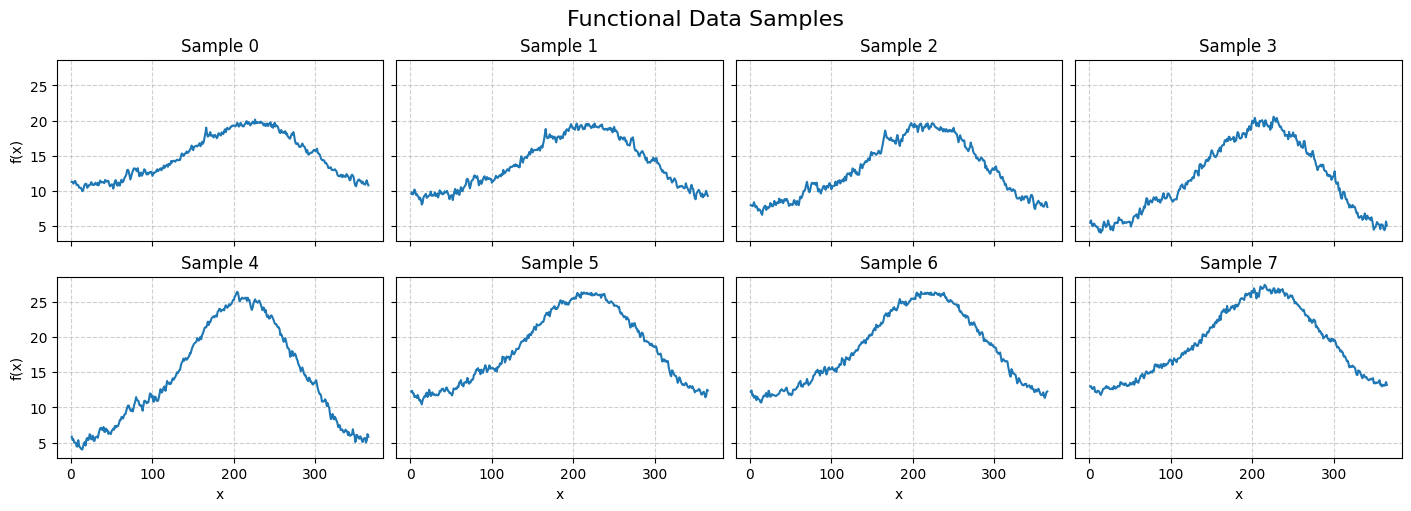

In [8]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 1.0, 365.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

In [ ]:
# save training dataset
save_tensor_bundle(
    "dataset_samples.pt",
    data=data_train,
    data_eps=data_eps,
    seed=seed,
    x_inf=x_inf,
    x_sup=x_sup,
)

Saved -> ../../results/data/dataset_samples.pt  (0.32 MB)


PosixPath('../../results/data/dataset_samples.pt')

## Flow Matching process

In [ ]:
def alpha_t(t):
    return 1 - t

def diff_alpha_t(t):
    return -1

def beta_t(t):
    return t

def diff_beta_t(t):
    return 1

t_0 = 0.0
T = 1.0
t_eps = 0.0
flow_process = flow.FlowMatchingProcess(
    alpha_t=alpha_t,
    beta_t=beta_t,
    diff_alpha_t=diff_alpha_t,
    diff_beta_t=diff_beta_t,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([73, 100, 1, 365])


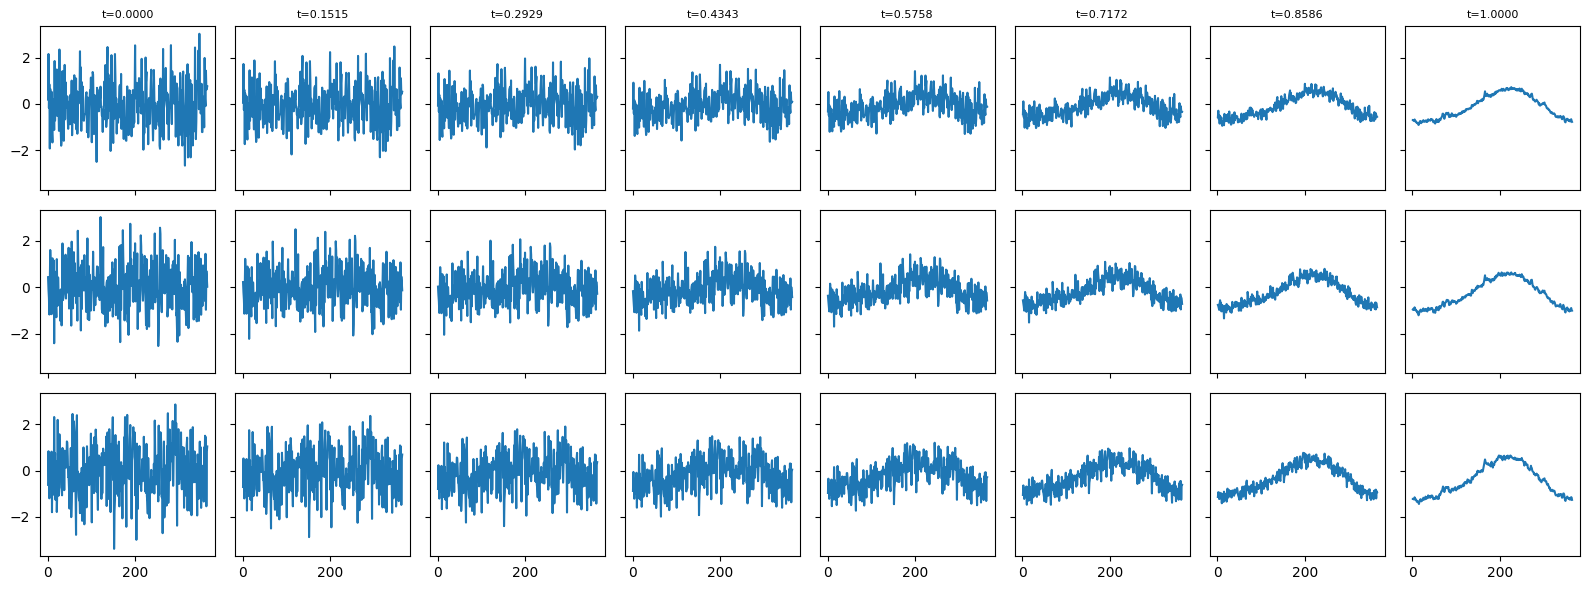

In [ ]:
# Example flow process

n_steps = 100

synthetic_functions_t = flow.flow_interpolation(data_train_norm[:].to(device), alpha_t, beta_t, t_0, T, n_steps)
print(synthetic_functions_t.shape)

plot_flow_process(
    synthetic_functions_t,
    axis_x=axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

In [ ]:
# Save flow forward interpolation path
save_tensor_bundle(
    "forward_flow_interpolation.pt",
    data=synthetic_functions_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

Saved -> ../../results/data/forward_flow_interpolation.pt  (10.66 MB)


PosixPath('../../results/data/forward_flow_interpolation.pt')

## Synthetic data generation

In [ ]:
# Define the model

v_model = UNetScoreModel(
    multiply_inv_sigma=None,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(v_model.parameters(), lr=learning_rate)

In [ ]:
# Compute results

checkpoint_path = os.path.join(
    CHECKPOINTS_DIR,
    experiment_name,
    f"checkpoint_epoch_{epoch_to_load}.pth"
)

def ode(x_t, t, v_model):
    v = v_model(x_t, t)
    return v

n_functions = 73
torch.manual_seed(seed)
x_0 = torch.randn(n_functions, 1, M, device=device)

n_steps = 100
t_0 = 0.0

v_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(checkpoint_path, v_model, optimizer)
v_model.eval()

torch.manual_seed(seed)

with torch.no_grad():
    times, synthetic_functions_t = flow.euler_integrator(
        x_initial=x_0,
        t_start=t_0,
        t_end=T,
        n_times=n_steps,
        ode_coefficient=partial(ode, v_model=v_model)
    )

print(synthetic_functions_t.shape)

synthetic_functions_norm = synthetic_functions_t[:, -1, :, :]

synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 5/Flow matching/checkpoints/training_flow_01_AEMET/checkpoint_epoch_10000.pth
Epoch: 10000. Loss: 18.891761. Time: 29:00
torch.Size([73, 100, 1, 365])


In [ ]:
# Save generated samples
save_tensor_bundle(
    "generated_flow_samples.pt",
    data=synthetic_functions_t,
    seed=seed,
)

Saved -> ../../results/data/generated_flow_samples.pt  (10.66 MB)


PosixPath('../../results/data/generated_flow_samples.pt')

## Results

In [ ]:
print("Epoch:", epoch)
print("Loss:", loss)

Epoch: 10000
Loss: 18.891760943687125


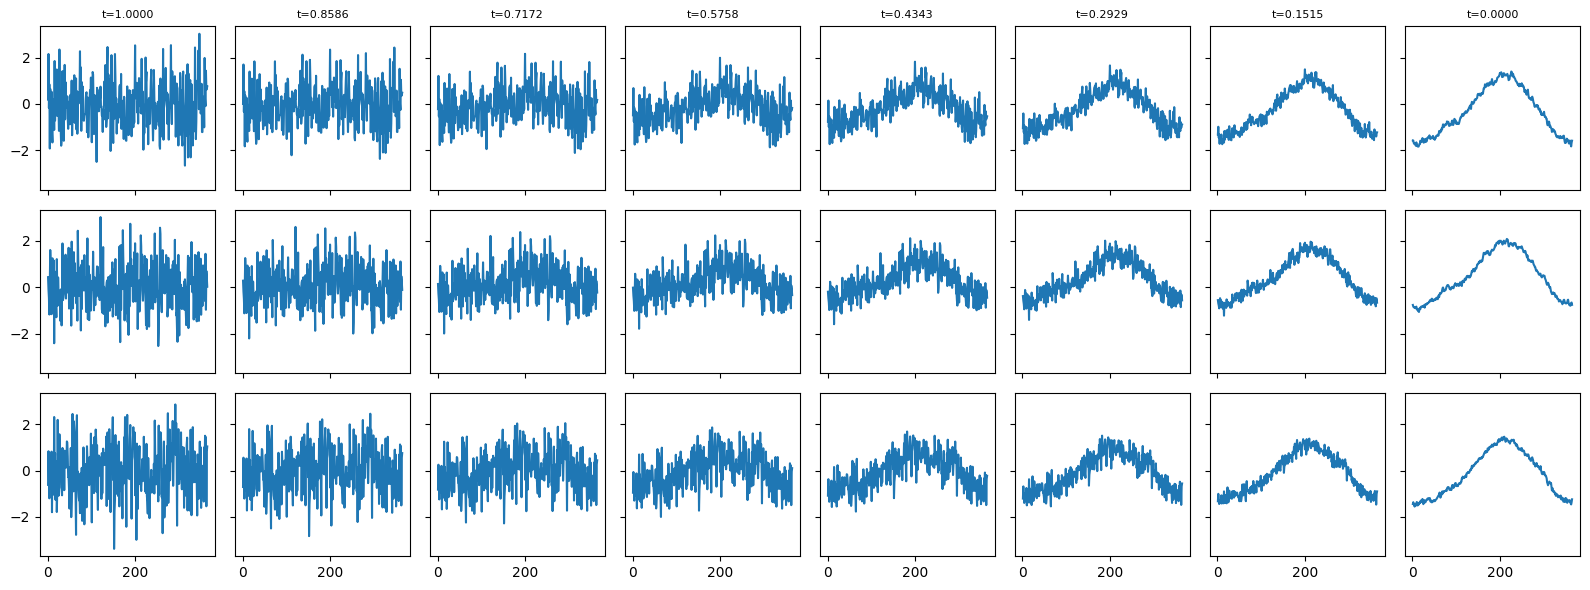

In [ ]:
plot_flow_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_0,
)

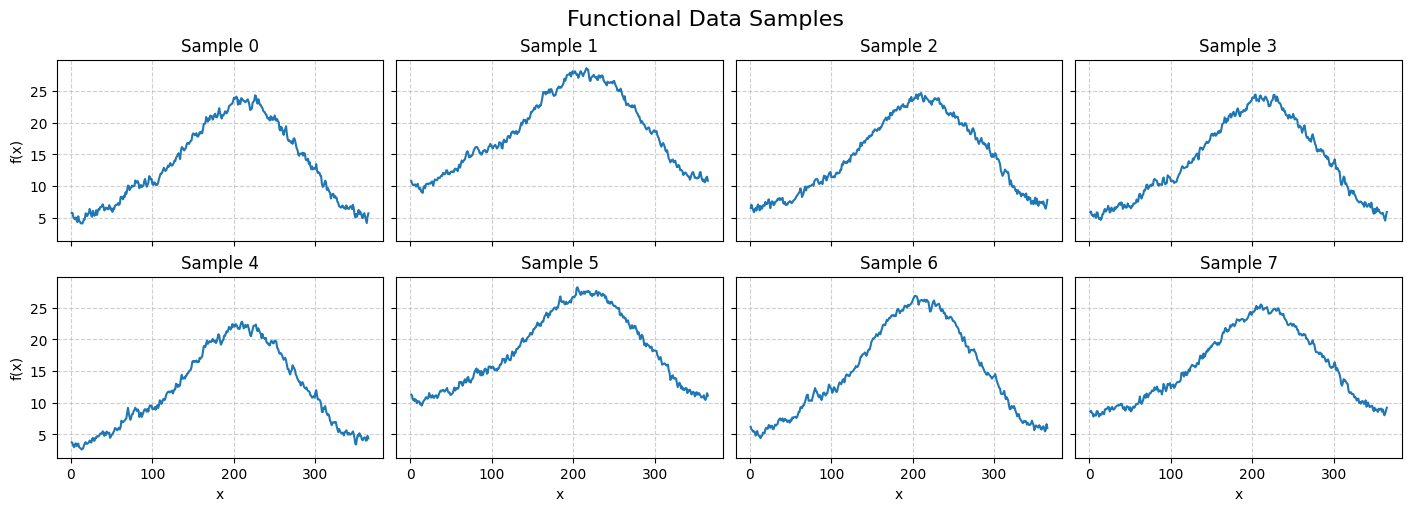

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x=axis_x,
)

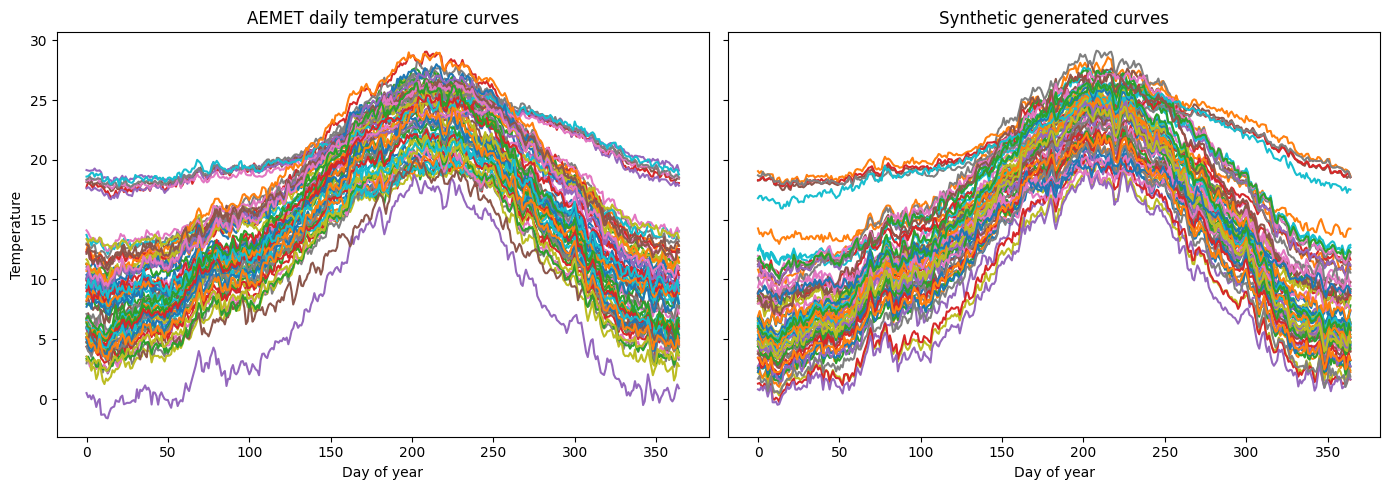

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(data_train.shape[0]):
    axes[0].plot(data_train[i, 0, :].numpy())
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Temperature")
axes[0].set_title("AEMET daily temperature curves")

for i in range(synthetic_functions.shape[0]):
    axes[1].plot(synthetic_functions[i, 0, :].cpu().numpy())
axes[1].set_xlabel("Day of year")
axes[1].set_title("Synthetic generated curves")

plt.tight_layout()
plt.show()